# Student Performance dataset


## Step 0 - Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


## Step 1 - Load the Dataset

In [12]:
df = pd.read_csv('student_performance_ml_200.csv')

print('Rows and Columns:', df.shape)
df.head()

Rows and Columns: (200, 12)


,student_id,age,gender,study_hours_per_day,attendance_rate,previous_grade,parent_education,internet_access,extracurricular,sleep_hours,part_time_job,final_grade
0,1,17,Male,3.5,85.0,72.0,Graduate,Yes,Yes,7.0,No,78
1,2,18,Female,5.0,92.0,88.0,Postgraduate,Yes,No,8.0,No,91
2,3,16,Male,1.5,60.0,55.0,High School,No,Yes,6.0,Yes,52
3,4,19,Female,4.0,78.0,80.0,Graduate,Yes,Yes,7.0,No,83
4,5,17,Male,2.0,70.0,65.0,High School,Yes,No,5.0,Yes,61


In [13]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
student_id             0
age                    0
gender                 0
study_hours_per_day    3
attendance_rate        3
previous_grade         2
parent_education       2
internet_access        1
extracurricular        1
sleep_hours            1
part_time_job          1
final_grade            0
dtype: int64


## Step 2 - Clean the Data
- Remove useless columns
- Fix wrong values (outliers)
- Fill missing values
- Convert text to numbers
- Create target label: **Low / Medium / High**

In [14]:
# Remove student_id
df.drop(columns=['student_id'], inplace=True)

In [15]:
# Fix outliers using IQR
for col in ['age', 'study_hours_per_day', 'attendance_rate', 'previous_grade']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

In [16]:
# Fill missing numeric values with median
num_cols = ['study_hours_per_day', 'attendance_rate', 'previous_grade', 'sleep_hours']
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

In [17]:
# Fill missing text values with most common value (mode)
cat_cols = ['parent_education', 'internet_access', 'extracurricular', 'part_time_job']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [18]:
# Convert Yes/No and Male/Female to 0 and 1 manually
le = LabelEncoder()
for col in ['gender', 'internet_access', 'extracurricular', 'part_time_job']:
    df[col] = le.fit_transform(df[col])

##df['internet_access']  = df['internet_access'].map({'No': 0, 'Yes': 1})
#df['extracurricular']  = df['extracurricular'].map({'No': 0, 'Yes': 1})
#df['part_time_job']    = df['part_time_job'].map({'No': 0, 'Yes': 1})

In [19]:
# Convert parent education to numbers
df['parent_education'] = df['parent_education'].map(
    {'High School': 0, 'Graduate': 1, 'Postgraduate': 2})

# Create performance label
def get_label(grade):
    if grade < 60:   return 'Low'
    elif grade < 80: return 'Medium'
    else:            return 'High'

df['performance'] = df['final_grade'].apply(get_label)

print('Data cleaned!')
print(df['performance'].value_counts())

Data cleaned!
performance
High      85
Medium    63
Low       52
Name: count, dtype: int64


---
## Q1 - Input Features, Target Variable & Train/Test Split
- **Input (X):** columns used to predict
- **Target (y):** column we want to predict → `performance`
- **Train set:** 80% → model learns from this
- **Test set:** 20% → we check model here

In [20]:
FEATURES = [c for c in df.columns if c not in ['final_grade', 'performance']]
TARGET   = 'performance'

X = df[FEATURES]
y = df[TARGET]

print('Target  :', TARGET)
print('Features:', FEATURES)

Target  : performance
Features: ['age', 'gender', 'study_hours_per_day', 'attendance_rate', 'previous_grade', 'parent_education', 'internet_access', 'extracurricular', 'sleep_hours', 'part_time_job']


In [21]:
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 160
Testing samples : 40


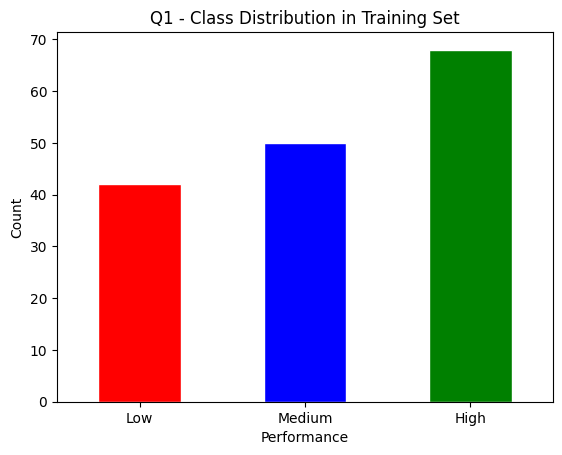

In [22]:
# Bar chart of class counts in training set
y_train.value_counts().reindex(['Low','Medium','High']).plot(
    kind='bar', color=['red','blue','green'], edgecolor='white')
plt.title('Q1 - Class Distribution in Training Set')
plt.xlabel('Performance')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

---
## Q2 - Decision Tree Classifier
A Decision Tree asks questions step by step:
> *study_hours > 3.5?* → Yes → *attendance > 75?* → predict **High**

It learns these rules automatically from training data.

In [23]:
# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Predict on test data
dt_pred = dt.predict(X_test)

print('Decision Tree trained!')

Decision Tree trained!


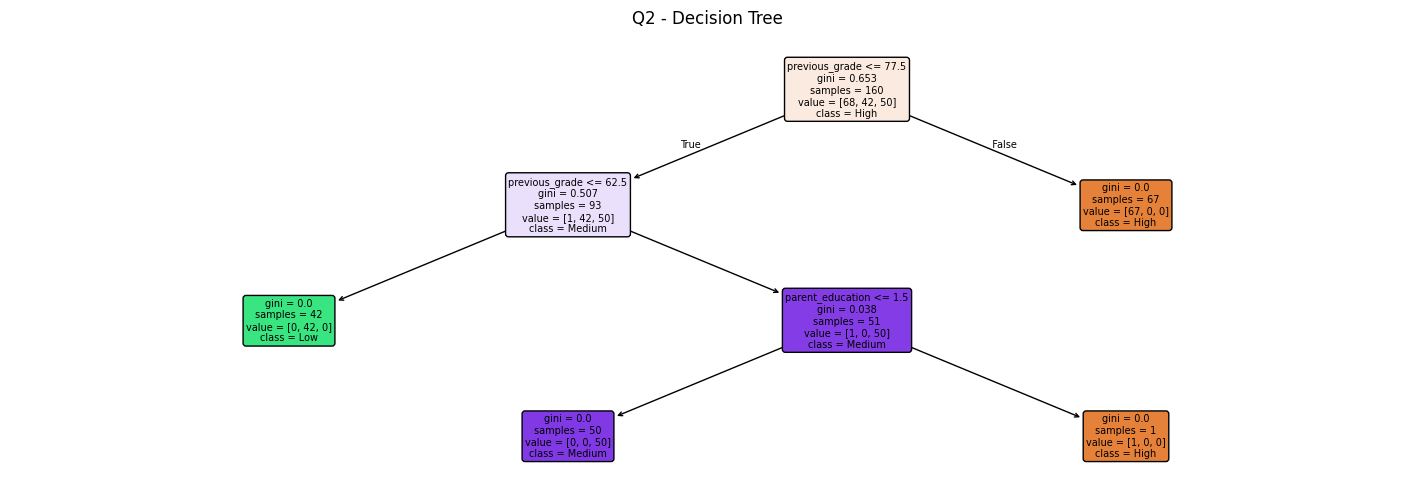

In [24]:
# Show the Decision Tree diagram
plt.figure(figsize=(18, 6))
plot_tree(dt, feature_names=FEATURES,
          class_names=sorted(y_train.unique()),
          filled=True, rounded=True, fontsize=7)
plt.title('Q2 - Decision Tree')
plt.show()

### Q2 - Evaluation Results

In [25]:
# Accuracy, Precision, Recall, F1-Score
print('===== Decision Tree - Results =====')
print('Accuracy :', round(accuracy_score(y_test, dt_pred) * 100, 2), '%')
print('Precision:', round(precision_score(y_test, dt_pred, average='weighted', zero_division=0), 3))
print('Recall   :', round(recall_score(y_test, dt_pred, average='weighted', zero_division=0), 3))
print('F1-Score :', round(f1_score(y_test, dt_pred, average='weighted', zero_division=0), 3))

===== Decision Tree - Results =====
Accuracy : 100.0 %
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


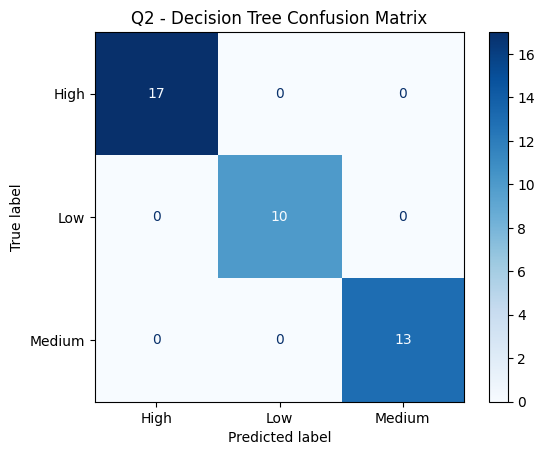

Diagonal = Correct | Off-diagonal = Wrong predictions


In [26]:
# Confusion Matrix
labels = ['High', 'Low', 'Medium']
cm = confusion_matrix(y_test, dt_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues')
plt.title('Q2 - Decision Tree Confusion Matrix')
plt.show()
print('Diagonal = Correct | Off-diagonal = Wrong predictions')

---
## Q3 - Normalize + k-NN Classifier
**k-NN:** finds the k most similar students and takes a majority vote.

**Normalization:** scales all values to [0, 1] so no feature dominates.

In [28]:
# Normalize features to [0, 1]
scaler = MinMaxScaler()
X_train_n = scaler.fit_transform(X_train)
X_test_n  = scaler.transform(X_test)

print('Before normalization (first row sample):', X_train.iloc[0].values[:4])
print('After  normalization (first row sample):', X_train_n[0][:4].round(3))

Before normalization (first row sample): [18.  0.  2. 68.]
After  normalization (first row sample): [0.571 0.    0.138 0.528]


Best k = 1


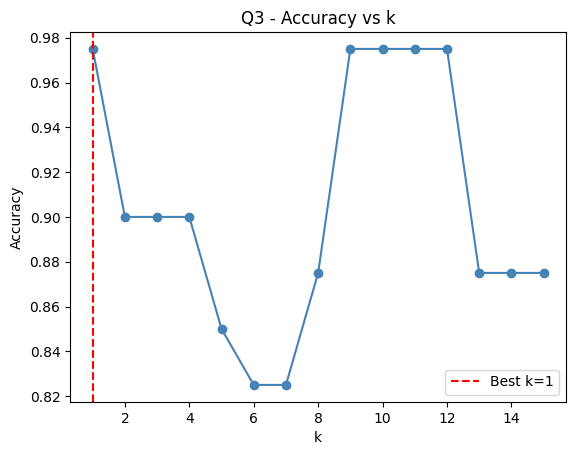

In [29]:
# Find best k
accuracies = []
for k in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_n, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test_n)))

best_k = accuracies.index(max(accuracies)) + 1
print('Best k =', best_k)

plt.plot(range(1, 16), accuracies, 'o-', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.title('Q3 - Accuracy vs k')
plt.xlabel('k'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

In [30]:
# Train k-NN with best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_n, y_train)
knn_pred = knn.predict(X_test_n)

print('k-NN trained with k =', best_k)

k-NN trained with k = 1


### Q3 - Evaluation Results

In [31]:
# Accuracy, Precision, Recall, F1-Score
print('===== k-NN - Results =====')
print('Accuracy :', round(accuracy_score(y_test, knn_pred) * 100, 2), '%')
print('Precision:', round(precision_score(y_test, knn_pred, average='weighted', zero_division=0), 3))
print('Recall   :', round(recall_score(y_test, knn_pred, average='weighted', zero_division=0), 3))
print('F1-Score :', round(f1_score(y_test, knn_pred, average='weighted', zero_division=0), 3))

===== k-NN - Results =====
Accuracy : 97.5 %
Precision: 0.977
Recall   : 0.975
F1-Score : 0.975


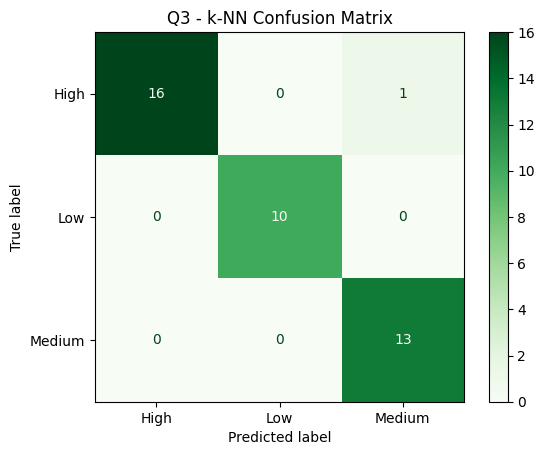

In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, knn_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Greens')
plt.title('Q3 - k-NN Confusion Matrix')
plt.show()

---
## Q4 - Naïve Bayes Classifier
Uses **probability** to classify students.
> Given the features, what is the probability of each class? → pick the highest.

Called *Naïve* because it assumes all features are independent of each other.

In [33]:
# Train Naïve Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

print('Naïve Bayes trained!')

Naïve Bayes trained!


In [34]:
# Show probabilities for first 5 students
proba = nb.predict_proba(X_test[:5])
result = pd.DataFrame(proba, columns=nb.classes_)
result['Predicted'] = nb_pred[:5]
result['Actual']    = y_test.values[:5]
print('Probabilities for first 5 test students:')
result.round(3)

Probabilities for first 5 test students:


,High,Low,Medium,Predicted,Actual
0,1.000,0.0,0.000,High,High
1,0.000,1.0,0.000,Low,Low
2,1.000,0.0,0.000,High,High
3,0.000,1.0,0.000,Low,Low
4,0.019,0.0,0.981,Medium,Medium


### Q4 - Evaluation Results

In [35]:
# Accuracy, Precision, Recall, F1-Score
print('===== Naïve Bayes - Results =====')
print('Accuracy :', round(accuracy_score(y_test, nb_pred) * 100, 2), '%')
print('Precision:', round(precision_score(y_test, nb_pred, average='weighted', zero_division=0), 3))
print('Recall   :', round(recall_score(y_test, nb_pred, average='weighted', zero_division=0), 3))
print('F1-Score :', round(f1_score(y_test, nb_pred, average='weighted', zero_division=0), 3))

===== Naïve Bayes - Results =====
Accuracy : 90.0 %
Precision: 0.914
Recall   : 0.9
F1-Score : 0.895


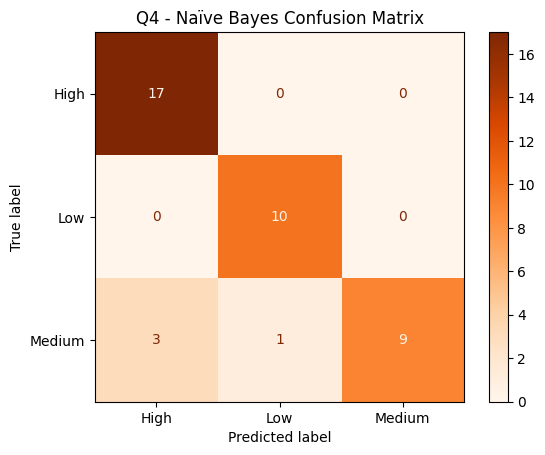

In [36]:
# Confusion Matrix
cm = confusion_matrix(y_test, nb_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Oranges')
plt.title('Q4 - Naïve Bayes Confusion Matrix')
plt.show()

---
## Q5 - Evaluation (Already shown after each model above)
Here is a quick **side-by-side comparison** of all 3 models:

| Metric | Meaning |
|---|---|
| Accuracy | % of correct predictions |
| Precision | How many predicted positives are actually correct? |
| Recall | How many actual positives did we catch? |
| F1-Score | Balance between Precision and Recall |

In [37]:
# Side-by-side comparison table
labels = ['High', 'Low', 'Medium']
all_preds = {'Decision Tree': dt_pred, 'k-NN': knn_pred, 'Naive Bayes': nb_pred}
rows = []

for name, pred in all_preds.items():
    rows.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, pred), 3),
        'Precision': round(precision_score(y_test, pred, average='weighted', zero_division=0), 3),
        'Recall'   : round(recall_score(y_test, pred, average='weighted', zero_division=0), 3),
        'F1-Score' : round(f1_score(y_test, pred, average='weighted', zero_division=0), 3)
    })

summary = pd.DataFrame(rows).set_index('Model')
summary

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,1.000,1.000,1.000,1.000
k-NN,0.975,0.977,0.975,0.975
Naive Bayes,0.900,0.914,0.900,0.895


---
## Q6 - K-Means Clustering
**Unsupervised** — we do NOT use the target label here.

K-Means automatically groups similar students into clusters.
> Students with similar study habits and grades end up in the same cluster.

In [30]:
# Remove target columns (unsupervised = no labels)
X_clust = df.drop(columns=['final_grade', 'performance'])

# Scale before clustering
X_clust_scaled = StandardScaler().fit_transform(X_clust)
print('Features ready for clustering!')

Features ready for clustering!


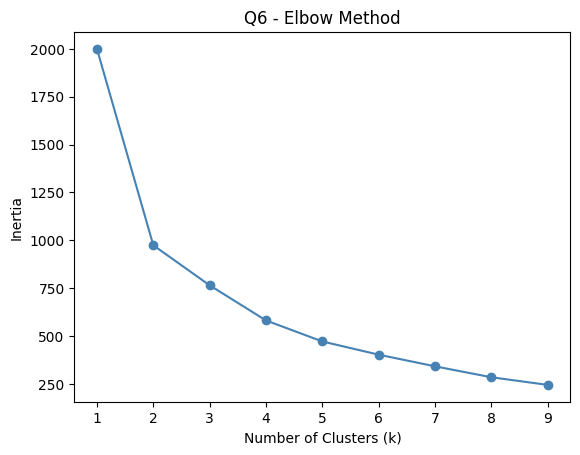

Pick k at the elbow bend of the curve


In [31]:
# Elbow method to find best k
inertias = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_scaled)
    inertias.append(km.inertia_)

plt.plot(range(1, 10), inertias, 'o-', color='steelblue')
plt.title('Q6 - Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()
print('Pick k at the elbow bend of the curve')

In [32]:
# Apply K-Means with k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X_clust_scaled)

print('Students per cluster:')
print(df['Cluster'].value_counts().sort_index())

Students per cluster:
Cluster
0    72
1    67
2    61
Name: count, dtype: int64


In [33]:
# Average values per cluster
profile = df.groupby('Cluster')[['study_hours_per_day', 'attendance_rate',
                                   'previous_grade', 'final_grade']].mean().round(2)
print('Cluster Profiles (average values):')
profile

Cluster Profiles (average values):


,study_hours_per_day,attendance_rate,previous_grade,final_grade
Cluster,,,,
0,1.72,62.06,56.50,53.28
1,4.93,90.06,86.34,89.07
2,3.45,79.55,75.30,77.41


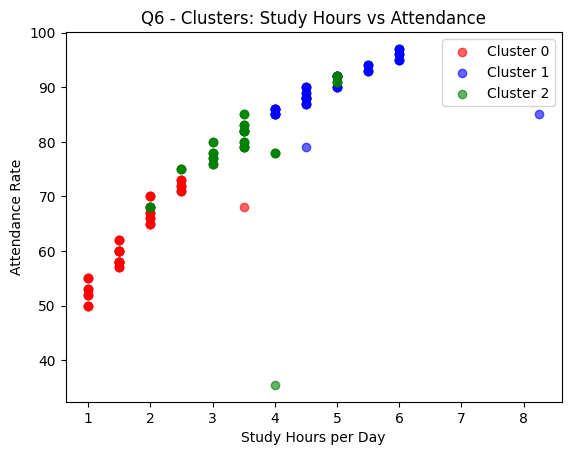

In [34]:
# Scatter plot: Study Hours vs Attendance coloured by cluster
colors = ['red', 'blue', 'green']
for c in range(3):
    mask = df['Cluster'] == c
    plt.scatter(df.loc[mask, 'study_hours_per_day'],
                df.loc[mask, 'attendance_rate'],
                color=colors[c], label=f'Cluster {c}', alpha=0.6)

plt.title('Q6 - Clusters: Study Hours vs Attendance')
plt.xlabel('Study Hours per Day')
plt.ylabel('Attendance Rate')
plt.legend()
plt.show()

---
## Summary
| Q | Topic | Algorithm |
|---|---|---|
| Q1 | Features & Split | train_test_split |
| Q2 | Classification + Evaluation | Decision Tree |
| Q3 | Normalization + Classification + Evaluation | k-NN |
| Q4 | Classification + Evaluation | Naïve Bayes |
| Q5 | Comparison of all models | All metrics |
| Q6 | Clustering | K-Means |